In [1]:
import py4hw

In [7]:
class FullAdder(py4hw.Logic):
    
    def __init__(self, parent, name, x, y, ci, s, co):
        super().__init__(parent, name)
        
        x = self.addIn('x', x)
        y = self.addIn('y', y)
        ci = self.addIn('ci', ci)
        s = self.addOut('s', s)
        co = self.addOut('co', co)

        w1 = self.wire('w1',1)
        w2 = self.wire('w2',1)
        w3 = self.wire('w3',1)
        
        py4hw.Xor2(self, 'g1', x, y, w1)
        py4hw.Xor2(self, 'g2', w1, ci, s)
        py4hw.And2(self, 'g3', w1, ci, w2)
        py4hw.And2(self, 'g4', x, y, w3)
        py4hw.Or2(self, 'g5', w2, w3, co)

In [13]:
class RippleCarryAdder4(py4hw.Logic):
    
    def __init__(self, parent, name, x, y, s):
        super().__init__(parent, name)
        
        x = self.addIn('x', x)
        y = self.addIn('y', y)
        s = self.addOut('s', s)

        c0 = self.wire('c0',1)
        c1 = self.wire('c1',1)
        c2 = self.wire('c2',1)
        c3 = self.wire('c3',1)
        c4 = self.wire('c4',1)        
        
        py4hw.Constant(self,'zero',0,c0)

        x0 = self.wire('x0',1)
        x1 = self.wire('x1',1)
        x2 = self.wire('x2',1)
        x3 = self.wire('x3',1)

        y0 = self.wire('y0',1)
        y1 = self.wire('y1',1)
        y2 = self.wire('y2',1)
        y3 = self.wire('y3',1)

        py4hw.Bit(self,'bit_x0',x,0,x0)
        py4hw.Bit(self,'bit_x1',x,1,x1)
        py4hw.Bit(self,'bit_x2',x,2,x2)
        py4hw.Bit(self,'bit_x3',x,3,x3)

        py4hw.Bit(self,'bit_y0',y,0,y0)
        py4hw.Bit(self,'bit_y1',y,1,y1)
        py4hw.Bit(self,'bit_y2',y,2,y2)
        py4hw.Bit(self,'bit_y3',y,3,y3)

        s0 = self.wire('s0',1)
        s1 = self.wire('s1',1)
        s2 = self.wire('s2',1)
        s3 = self.wire('s3',1)

        FullAdder(self,'fa0',x0,y0,c0,s0,c1)
        FullAdder(self,'fa1',x1,y1,c1,s1,c2)
        FullAdder(self,'fa2',x2,y2,c2,s2,c3)
        FullAdder(self,'fa3',x3,y3,c3,s3,c4)

        py4hw.ConcatenateLSBF(self,'concat_out',[s0,s1,s2,s3,c4],s)

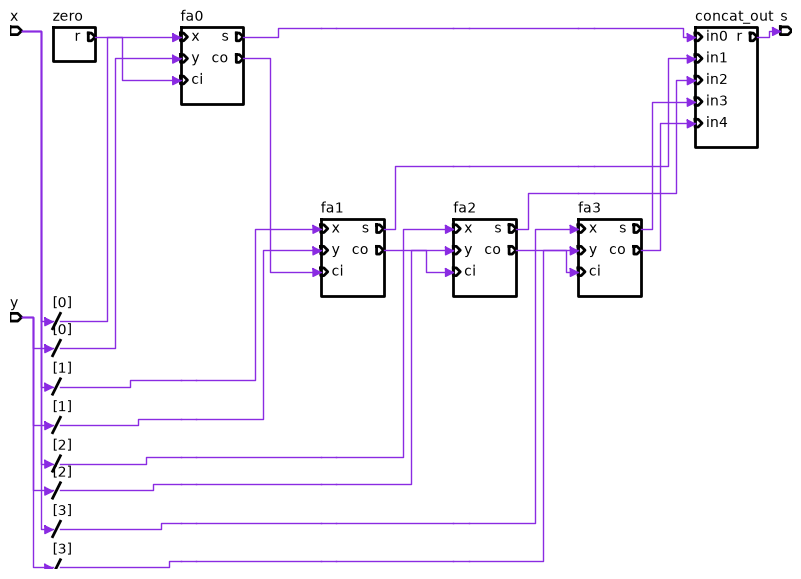

In [14]:
sys=py4hw.HWSystem()

x=sys.wire('x',4)
y=sys.wire('y',4)
s=sys.wire('s',5)

rca=RippleCarryAdder4(sys,'rca4',x,y,s)

sch=py4hw.Schematic(rca)
sch.draw()

In [15]:

sys = py4hw.HWSystem()
x = sys.wire('x',4)
y = sys.wire('y',4)
s = sys.wire('s',5)
py4hw.Sequence(sys, 'y', [0,1,2,3,4], y)
py4hw.Sequence(sys, 'x', [9,5,4], x)

rca=RippleCarryAdder4(sys,'rca',x,y,s)

wf = py4hw.Waveform(sys, 'wf', [x, y, s])
sys.getSimulator().clk(20)

wf.draw_wavedrom()